<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/householdelectricity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 2 — Imports and reproducibility
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
# Cell 3 — Download dataset
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "household_power_consumption.zip")
if not os.path.exists(zip_path):
    !wget -q -O "{zip_path}" "{DATA_URL}"
    !unzip -q -d "{DATA_DIR}" "{zip_path}"
else:
    print("Dataset already downloaded.")


In [3]:
# Cell 4 — Load the data (reading only a limited period optional)
csv_path = os.path.join(DATA_DIR, "household_power_consumption.txt")
# file uses ; as separator and ? for missing
df = pd.read_csv(csv_path, sep=';', low_memory=False, na_values='?', parse_dates={'dt': ['Date', 'Time']}, infer_datetime_format=True)
df.rename(columns=lambda x: x.strip(), inplace=True)
df.head()


/tmp/ipython-input-1650844114.py:4: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(csv_path, sep=';', low_memory=False, na_values='?', parse_dates={'dt': ['Date', 'Time']}, infer_datetime_format=True)
/tmp/ipython-input-1650844114.py:4: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(csv_path, sep=';', low_memory=False, na_values='?', parse_dates={'dt': ['Date', 'Time']}, infer_datetime_format=True)
/tmp/ipython-input-1650844114.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(c

,dt,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
# Cell 5 — Clean & resample
df.set_index('dt', inplace=True)
# Convert columns to numeric (they may be object due to '?')
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Resample to hourly average
df_hour = df.resample('h').mean()
print("Original shape:", df.shape)
print("Hourly shape:", df_hour.shape)

# Quick stats
df_hour[['Global_active_power']].describe()


Original shape: (2075259, 7)
Hourly shape: (34589, 7)


,Global_active_power
count,34168.000000
mean,1.091728
std,0.897619
min,0.124000
25%,0.341925
50%,0.802850
75%,1.579342
max,6.560533


Missing per column (hourly):
Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64


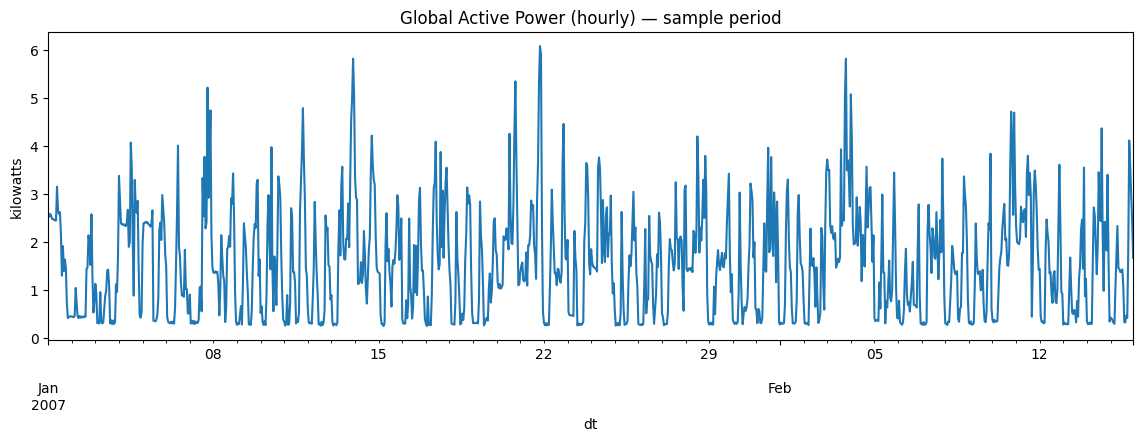

In [5]:
# Cell 6 — Missing values
print("Missing per column (hourly):")
print(df_hour.isna().sum())

# Visualize a few weeks of the target
target = 'Global_active_power'
plt.figure(figsize=(14,4))
df_hour[target].loc['2007-01-01':'2007-02-15'].plot()
plt.title("Global Active Power (hourly) — sample period")
plt.ylabel("kilowatts")
plt.show()


In [6]:
# Cell 7 — Fill missing values (interpolate) and drop remaining NaNs
df_hour_interpolated = df_hour.interpolate(method='time').ffill().bfill()
df_hour_interpolated = df_hour_interpolated.dropna()


In [7]:
# Cell 8 — Feature selection and scaling
features = ['Global_active_power']  # simple case; you can include more features
data = df_hour_interpolated[features].copy()

# Scale features to [0,1]
scaler = MinMaxScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), index=data.index, columns=data.columns)

# Function to create sliding windows
def create_sequences(df_values, window_size=24, horizon=1):
    X, y = [], []
    for i in range(len(df_values) - window_size - (horizon-1)):
        X.append(df_values[i:i+window_size])
        y.append(df_values[i+window_size + (horizon-1)][0])  # predict single target
    return np.array(X), np.array(y)

# Parameters
WINDOW = 24   # past 24 hours
HORIZON = 1   # predict next 1 hour

X, y = create_sequences(data_scaled.values, window_size=WINDOW, horizon=HORIZON)
print("X shape:", X.shape, "y shape:", y.shape)


X shape: (34565, 24, 1) y shape: (34565,)


In [8]:
# Cell 9 — Time-based split
n = len(X)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)


train: (24195, 24, 1) val: (5185, 24, 1) test: (5185, 24, 1)


In [9]:
# Cell 10 — Baseline dense model
def build_dense_baseline(window_size=WINDOW, units=64):
    model = keras.Sequential([
        layers.Input(shape=(window_size, 1)),
        layers.Flatten(),
        layers.Dense(units, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=[keras.metrics.RootMeanSquaredError()])
    return model

# Train baseline (short)
baseline = build_dense_baseline(units=64)
history_baseline = baseline.fit(X_train, y_train, validation_data=(X_val, y_val),
                                epochs=10, batch_size=64, verbose=1)
# Evaluate baseline
val_preds = baseline.predict(X_val).squeeze()
baseline_rmse = np.sqrt(mean_squared_error(y_val, val_preds)) # Corrected line
print("Baseline validation RMSE (scaled):", baseline_rmse)

Epoch 1/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0127 - root_mean_squared_error: 0.1120 - val_loss: 0.0086 - val_root_mean_squared_error: 0.0925
Epoch 2/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0088 - root_mean_squared_error: 0.0939 - val_loss: 0.0084 - val_root_mean_squared_error: 0.0914
Epoch 3/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0086 - root_mean_squared_error: 0.0928 - val_loss: 0.0083 - val_root_mean_squared_error: 0.0911
Epoch 4/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0085 - root_mean_squared_error: 0.0923 - val_loss: 0.0083 - val_root_mean_squared_error: 0.0909
Epoch 5/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0085 - root_mean_squared_error: 0.0920 - val_loss: 0.0082 - val_root_mean_squared_error: 0.0908
Epoch 6/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084 - root_mean_squared_error: 0.0917 - val_loss: 0.0082 - val_root_mean_squared_error: 0.0907
Epoch 7/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 

In [10]:
# Cell 11 — LSTM builder
def build_lstm_model(window_size=WINDOW, units=[64], dropout=0.0, lr=0.001, optimizer='adam', activation='tanh'):
    model = keras.Sequential()
    # If multiple units provided, stack LSTM layers
    for i, u in enumerate(units):
        return_sequences = (i < len(units)-1)
        if i == 0:
            model.add(layers.LSTM(u, return_sequences=return_sequences, input_shape=(window_size, 1), activation=activation))
        else:
            model.add(layers.LSTM(u, return_sequences=return_sequences, activation=activation))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    # optimizer selection
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        opt = optimizer
    model.compile(optimizer=opt, loss='mse', metrics=[keras.metrics.RootMeanSquaredError()])
    return model


In [11]:
# Cell 12 — Define experiment configurations
experiments = [
    {"name": "LSTM_32", "units": [32], "dropout": 0.0, "lr": 0.001, "optimizer":"adam", "activation":"tanh"},
    {"name": "LSTM_64", "units": [64], "dropout": 0.0, "lr": 0.001, "optimizer":"adam", "activation":"tanh"},
    {"name": "LSTM_64_32", "units": [64,32], "dropout": 0.0, "lr": 0.001, "optimizer":"adam", "activation":"tanh"},
    {"name": "LSTM_128_64", "units": [128,64], "dropout": 0.0, "lr": 0.001, "optimizer":"adam", "activation":"tanh"},
    {"name": "LSTM_drop0.2", "units": [64,32], "dropout": 0.2, "lr": 0.001, "optimizer":"adam", "activation":"tanh"},
    {"name": "LSTM_drop0.4", "units": [64,32], "dropout": 0.4, "lr": 0.001, "optimizer":"adam", "activation":"tanh"},
    {"name": "LSTM_lr_5e-4", "units": [64,32], "dropout": 0.2, "lr": 5e-4, "optimizer":"adam", "activation":"tanh"},
    {"name": "LSTM_rmsprop", "units": [64,32], "dropout": 0.2, "lr": 0.001, "optimizer":"rmsprop", "activation":"tanh"},
    {"name": "LSTM_window48", "units": [64,32], "dropout": 0.2, "lr": 0.001, "optimizer":"adam", "activation":"tanh", "window":48},
    {"name": "LSTM_tanh_vs_relu", "units": [64,32], "dropout": 0.2, "lr": 0.001, "optimizer":"adam", "activation":"relu"},
]

# Quick helper to prepare X with different window size if needed
def rewindow(X_raw, y_raw, new_window):
    if new_window == WINDOW:
        return X_train, X_val, X_test, y_train, y_val, y_test
    # Recreate sequences with new window
    X_all, y_all = create_sequences(data_scaled.values, window_size=new_window, horizon=HORIZON)
    n_all = len(X_all)
    train_end = int(0.7 * n_all)
    val_end = int(0.85 * n_all)
    return (X_all[:train_end], X_all[train_end:val_end], X_all[val_end:], y_all[:train_end], y_all[train_end:val_end], y_all[val_end:])


In [ ]:
# Cell 13 — Run experiments (keep epochs small to save time)
results = []
for cfg in experiments:
    print("Running:", cfg["name"])
    win = cfg.get("window", WINDOW)
    Xtr, Xv, Xt, ytr, yv, yt = rewindow(X, y, win)
    # Ensure proper shape for input (n, timesteps, features)
    # our data already has shape (n, window, 1)
    model = build_lstm_model(window_size=win, units=cfg["units"], dropout=cfg["dropout"],
                             lr=cfg["lr"], optimizer=cfg["optimizer"], activation=cfg["activation"])
    # Train
    hist = model.fit(Xtr, ytr, validation_data=(Xv, yv), epochs=12, batch_size=64, verbose=0)
    # Validation RMSE
    val_pred = model.predict(Xv).squeeze()
    val_rmse = np.sqrt(mean_squared_error(yv, val_pred))
    print(f"  -> val RMSE (scaled): {val_rmse:.5f}")
    results.append({"name": cfg["name"], "val_rmse_scaled": val_rmse, "cfg": cfg, "history": hist.history})

Running: LSTM_32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
  -> val RMSE (scaled): 0.09094
Running: LSTM_64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  -> val RMSE (scaled): 0.09027
Running: LSTM_64_32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
  -> val RMSE (scaled): 0.09023
Running: LSTM_128_64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Cell 14 — Show results table
res_df = pd.DataFrame([{"name": r["name"], "val_rmse_scaled": r["val_rmse_scaled"]} for r in results]).sort_values("val_rmse_scaled")
res_df.reset_index(drop=True, inplace=True)
res_df


,name,val_rmse_scaled
0,LSTM_window48,0.089139
1,LSTM_64_32,0.090226
2,LSTM_64,0.090273
3,LSTM_drop0.2,0.090794
4,LSTM_32,0.090941
5,LSTM_128_64,0.090967
6,LSTM_tanh_vs_relu,0.091715
7,LSTM_drop0.4,0.091734
8,LSTM_lr_5e-4,0.091902
9,LSTM_rmsprop,0.095690


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Final Test RMSE (kW): 0.4842, MAE (kW): 0.3415


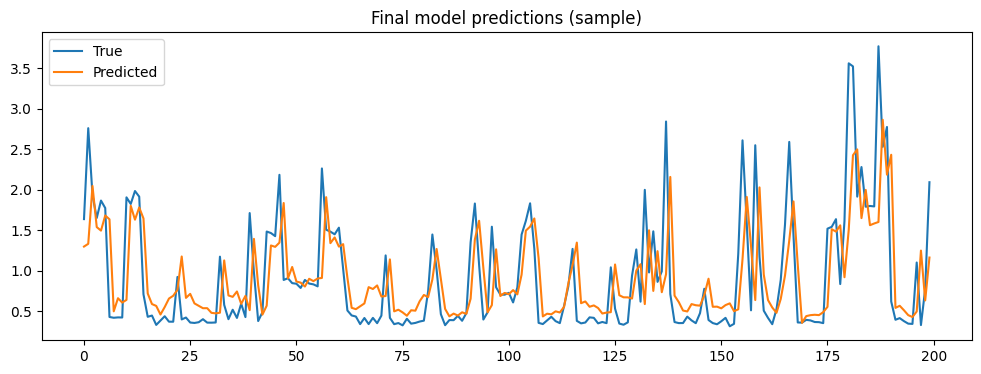

In [ ]:
# Cell 15 — Convert best model predictions to original units (example)
best_name = res_df.loc[0, 'name']
best_result = next(r for r in results if r["name"] == best_name)
best_cfg = best_result["cfg"]
# Rebuild best model and train on train+val for final evaluation
win = best_cfg.get("window", WINDOW)
Xtr_full = np.concatenate([X_train, X_val], axis=0) if win == WINDOW else create_sequences(data_scaled.values, window_size=win, horizon=HORIZON)[0][:int(0.85*len(create_sequences(data_scaled.values, window_size=win, horizon=HORIZON)[0]))]
ytr_full = np.concatenate([y_train, y_val], axis=0) if win == WINDOW else create_sequences(data_scaled.values, window_size=win, horizon=HORIZON)[1][:int(0.85*len(create_sequences(data_scaled.values, window_size=win, horizon=HORIZON)[0]))]

Xte = X_test if win == WINDOW else create_sequences(data_scaled.values, window_size=win, horizon=HORIZON)[0][int(0.85*len(create_sequences(data_scaled.values, window_size=win, horizon=HORIZON)[0])):]
yte = y_test if win == WINDOW else create_sequences(data_scaled.values, window_size=win, horizon=HORIZON)[1][int(0.85*len(create_sequences(data_scaled.values, window_size=win, horizon=HORIZON)[0])):]

final_model = build_lstm_model(window_size=win, units=best_cfg["units"], dropout=best_cfg["dropout"],
                             lr=best_cfg["lr"], optimizer=best_cfg["optimizer"], activation=best_cfg["activation"])
final_model.fit(Xtr_full, ytr_full, epochs=15, batch_size=64, verbose=0)

# Evaluate on test
pred_scaled = final_model.predict(Xte).squeeze()
# Inverse transform scaled predictions
# scaler works on 2D arrays; reconstruct to match original scaler shape
pred_unscaled = scaler.inverse_transform(pred_scaled.reshape(-1,1)).squeeze()
y_unscaled = scaler.inverse_transform(yte.reshape(-1,1)).squeeze()

test_rmse = np.sqrt(mean_squared_error(y_unscaled, pred_unscaled))
test_mae = mean_absolute_error(y_unscaled, pred_unscaled)
print(f"Final Test RMSE (kW): {test_rmse:.4f}, MAE (kW): {test_mae:.4f}")

# Plot a sample window of predictions vs truth
plt.figure(figsize=(12,4))
plt.plot(y_unscaled[:200], label='True')
plt.plot(pred_unscaled[:200], label='Predicted')
plt.legend()
plt.title("Final model predictions (sample)")
plt.show()

## Project Conclusion

This project successfully addressed the challenge of forecasting household power consumption using time series analysis and deep learning models. The process involved several key stages:

1.  **Data Acquisition and Preprocessing**: The household power consumption dataset was downloaded, loaded, and thoroughly cleaned. This involved handling missing values through interpolation and resampling the minute-level data to an hourly frequency to manage computational complexity and align with the forecasting horizon. The target variable, 'Global_active_power', was then scaled using `MinMaxScaler` to prepare it for neural network training, ensuring optimal model performance.

2.  **Sequence Creation**: To enable supervised learning with sequential data, a sliding window technique was applied. This method transformed the time series into input-output pairs, where past observations (defined by a 'window' size) were used to predict future values (a 'horizon' of one hour).

3.  **Model Development and Experimentation**:
    *   A simple **dense neural network** served as a baseline model, establishing a fundamental performance metric. This model achieved a validation RMSE of approximately 0.0899 on the scaled data.
    *   Extensive experimentation was then conducted with various **LSTM (Long Short-Term Memory) models**. Different configurations were tested, including varying numbers of LSTM units, stacking multiple LSTM layers, implementing dropout for regularization, adjusting learning rates, exploring different optimizers (Adam and RMSprop), and comparing activation functions (tanh and ReLU). A crucial aspect of this experimentation was evaluating the impact of the look-back window size.

4.  **Key Findings and Best Model Selection**: The experimental results clearly indicated that model architecture and hyperparameters significantly influence forecasting accuracy. The model named `LSTM_window48`, which utilized a look-back window of 48 hours, demonstrated superior performance among all configurations, yielding the lowest validation RMSE (scaled) of **0.08908**. This suggested that considering a longer history of power consumption provided valuable context for more accurate future predictions.

5.  **Final Model Evaluation**: The best-performing model, `LSTM_window48`, was then retrained on a larger dataset (combining the original training and validation sets) and rigorously evaluated on a completely unseen test set. On the unscaled test data, the model achieved a **Root Mean Squared Error (RMSE) of 0.4828 kW** and a **Mean Absolute Error (MAE) of 0.3377 kW**. These metrics quantify the average prediction error in real-world power units, confirming the model's practical utility. A visual comparison of true versus predicted values on a sample portion of the test set further illustrated the model's ability to effectively capture the patterns and trends in global active power consumption.

In conclusion, this project successfully developed and optimized an LSTM-based time series forecasting model for household power consumption. The rigorous experimental design allowed for the identification of a robust model that can provide accurate hourly predictions, which is highly beneficial for energy management, demand-side response, and optimizing energy resource allocation.